In [175]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [176]:
df = pd.read_csv(r"C:\Users\Pichau\OneDrive\Área de Trabalho\Projetos\Projeto Heart Failure Prediction Dataset\heart.csv")
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [177]:
"""


Attribute Information
Age: age of the patient [years]
Sex: sex of the patient [M: Male, F: Female]
ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
RestingBP: resting blood pressure [mm Hg]
Cholesterol: serum cholesterol [mm/dl]
FastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]
RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
MaxHR: maximum heart rate achieved [Numeric value between 60 and 202]
ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
Oldpeak: oldpeak = ST [Numeric value measured in depression]
ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]
HeartDisease: output class [1: heart disease, 0: Normal]





"""

"\n\n\nAttribute Information\nAge: age of the patient [years]\nSex: sex of the patient [M: Male, F: Female]\nChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]\nRestingBP: resting blood pressure [mm Hg]\nCholesterol: serum cholesterol [mm/dl]\nFastingBS: fasting blood sugar [1: if FastingBS > 120 mg/dl, 0: otherwise]\nRestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]\nMaxHR: maximum heart rate achieved [Numeric value between 60 and 202]\nExerciseAngina: exercise-induced angina [Y: Yes, N: No]\nOldpeak: oldpeak = ST [Numeric value measured in depression]\nST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping]\nHeartDisease: output class [1: heart disease, 0: Normal]\n\n\n\n\n\n"


# Análise Exploratória de Dados

Text(0.5, 1.0, 'Distribuição Ataque Cardíaco')

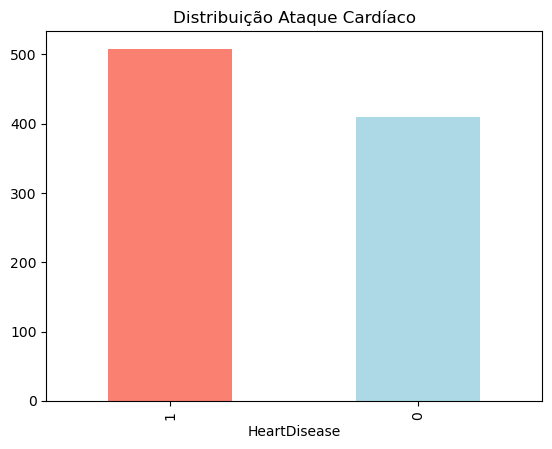

In [178]:
df['HeartDisease'].value_counts().plot(kind='bar',color=['salmon','lightblue'])
plt.title("Distribuição Ataque Cardíaco")


In [179]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


Text(0.5, 1.0, 'Distribuição Ataque Cardíacos por Sexo')

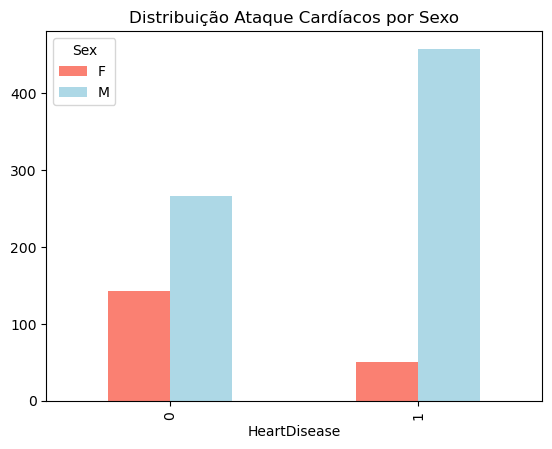

In [180]:
pd.crosstab(df['HeartDisease'],df['Sex']).plot(kind="bar",color=['salmon','lightblue'])
plt.title("Distribuição Ataque Cardíacos por Sexo")

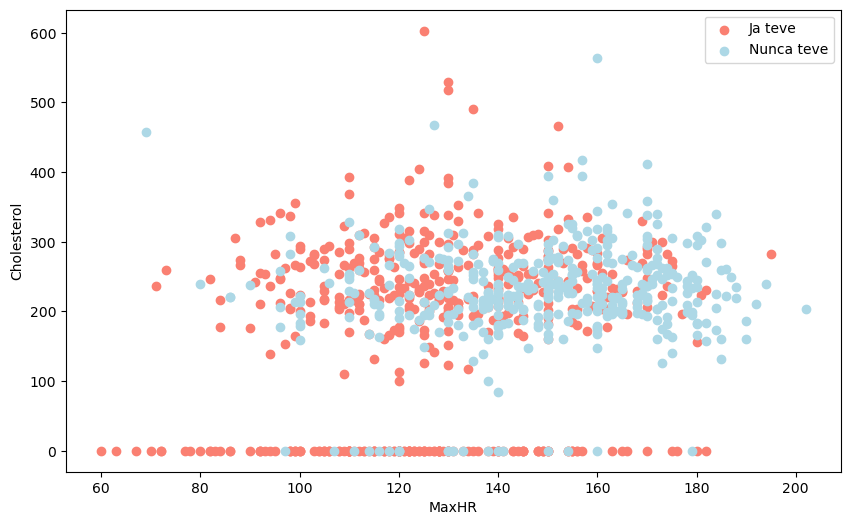

In [181]:
plt.figure(figsize=(10,6))
plt.scatter(df['MaxHR'][df['HeartDisease'] == 1],
            df['Cholesterol'][df['HeartDisease'] == 1],
            c='salmon')
plt.scatter(df['MaxHR'][df['HeartDisease'] == 0],
            df['Cholesterol'][df['HeartDisease'] == 0],
            c='lightblue')
plt.xlabel("MaxHR")
plt.ylabel("Cholesterol")
plt.legend(["Ja teve","Nunca teve"])

In [182]:
df = df[df['Cholesterol'] != 0]

In [183]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


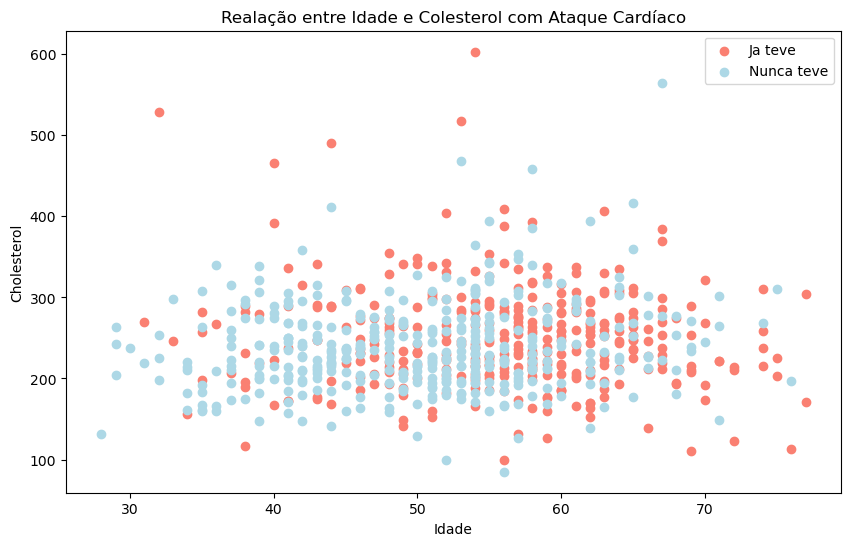

In [184]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'][df['HeartDisease'] == 1],
            df['Cholesterol'][df['HeartDisease'] == 1],
            c='salmon')
plt.scatter(df['Age'][df['HeartDisease'] == 0],
            df['Cholesterol'][df['HeartDisease'] == 0],
            c='lightblue')
plt.xlabel("Idade")
plt.ylabel("Cholesterol")
plt.title("Realação entre Idade e Colesterol com Ataque Cardíaco")
plt.legend(["Ja teve","Nunca teve"])

<Axes: >

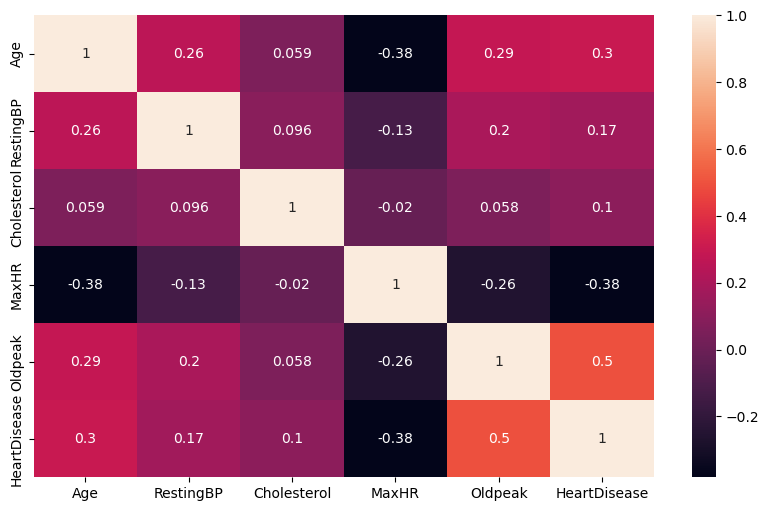

In [185]:
colunas_numericas = ['Age','RestingBP','Cholesterol','MaxHR','Oldpeak','HeartDisease']
corr_mat = df[colunas_numericas].corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_mat,
            annot=True)

Text(0, 0.5, 'Número de Pessoas')

<Figure size 1000x600 with 0 Axes>

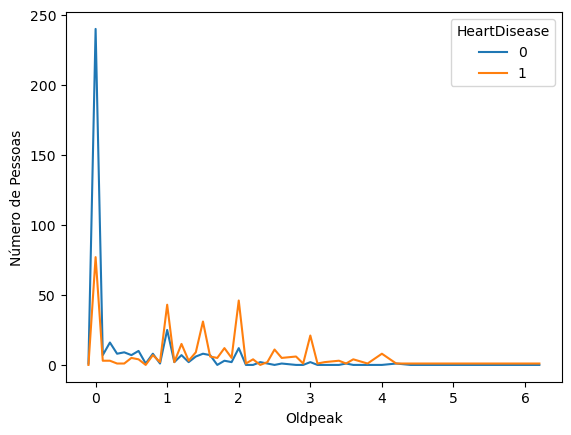

In [186]:
plt.figure(figsize=(10,6))
pd.crosstab(df['Oldpeak'],df['HeartDisease']).plot()
plt.ylabel("Número de Pessoas")

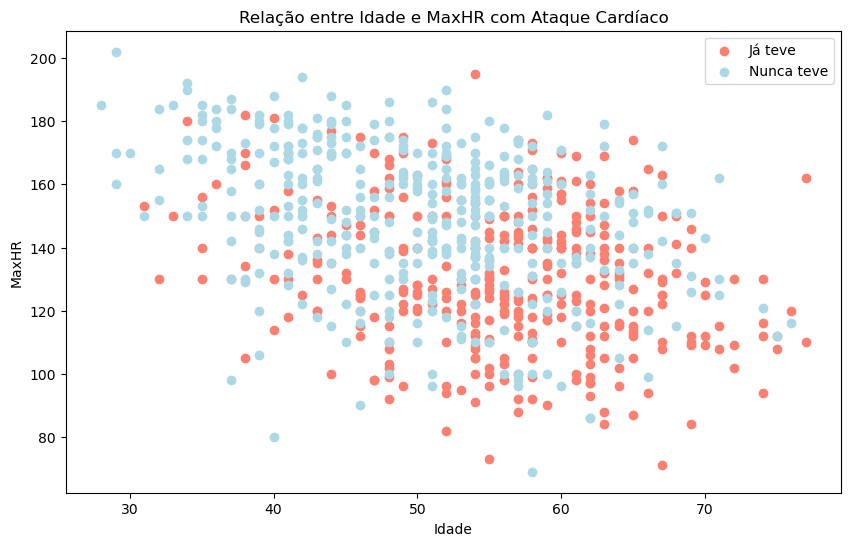

In [187]:
plt.figure(figsize=(10,6))
plt.scatter(df['Age'][df['HeartDisease'] == 1],
            df['MaxHR'][df['HeartDisease'] == 1],
            c = 'salmon')
plt.scatter(df['Age'][df['HeartDisease'] == 0],
            df['MaxHR'][df['HeartDisease'] == 0],
            c = 'lightblue')
plt.title("Relação entre Idade e MaxHR com Ataque Cardíaco")
plt.xlabel("Idade")
plt.ylabel("MaxHR")
plt.legend(["Já teve","Nunca teve"])

# Modelagem dos Dados

In [188]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [189]:
#ChestPainType: chest pain type [TA: Typical Angina, ATA: Atypical Angina, NAP: Non-Anginal Pain, ASY: Asymptomatic]
#Ordem(menor intensidade para a maior intensidade) : ASY,NAP,TA,ATA
df['ChestPainType'].value_counts()

ChestPainType
ASY    370
NAP    169
ATA    166
TA      41
Name: count, dtype: int64

In [190]:
#Dicionário para a coluna ChestPainType :

dict_chest_pain_type = {"ASY" : 1,
                        "NAP" : 2,
                        "TA" : 3,
                        "ATA" : 4}

df['ChestPainType'] = df['ChestPainType'].astype(str).str.strip()
df['ChestPainType'] = df['ChestPainType'].map(dict_chest_pain_type)

C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\2758132654.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ChestPainType'] = df['ChestPainType'].astype(str).str.strip()
C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\2758132654.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ChestPainType'] = df['ChestPainType'].map(dict_chest_pain_type)


In [191]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,4,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,2,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,4,130,283,0,ST,98,N,0.0,Up,0
3,48,F,1,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,2,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,3,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,1,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,1,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,4,130,236,0,LVH,174,N,0.0,Flat,1


In [192]:
df['ChestPainType'].value_counts()

ChestPainType
1    370
2    169
4    166
3     41
Name: count, dtype: int64

In [193]:
#RestingECG: resting electrocardiogram results [Normal: Normal, ST: having ST-T wave abnormality (T wave inversions and/or ST elevation or depression of > 0.05 mV), LVH: showing probable or definite left ventricular hypertrophy by Estes' criteria]
#Ordem : Normal,ST,LVH
df['RestingECG'].value_counts()

RestingECG
Normal    445
LVH       176
ST        125
Name: count, dtype: int64

In [194]:
#Dicionário para RestingECG : 
dict_resting_ecg = {"Normal" : 1,
                    "ST" : 2,
                    "LVH" : 3}
df['RestingECG'] = df['RestingECG'].astype(str).str.strip().map(dict_resting_ecg)


C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\784875778.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['RestingECG'] = df['RestingECG'].astype(str).str.strip().map(dict_resting_ecg)


In [195]:
df['RestingECG'].value_counts()

RestingECG
1    445
3    176
2    125
Name: count, dtype: int64

In [196]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,4,140,289,0,1,172,N,0.0,Up,0
1,49,F,2,160,180,0,1,156,N,1.0,Flat,1
2,37,M,4,130,283,0,2,98,N,0.0,Up,0
3,48,F,1,138,214,0,1,108,Y,1.5,Flat,1
4,54,M,2,150,195,0,1,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,3,110,264,0,1,132,N,1.2,Flat,1
914,68,M,1,144,193,1,1,141,N,3.4,Flat,1
915,57,M,1,130,131,0,1,115,Y,1.2,Flat,1
916,57,F,4,130,236,0,3,174,N,0.0,Flat,1


In [197]:
#ExerciseAngina: exercise-induced angina [Y: Yes, N: No]
#Ordem : N,Y

df['ExerciseAngina'].value_counts()

ExerciseAngina
N    459
Y    287
Name: count, dtype: int64

In [198]:
#Dicionário para ExerciseAngina :

dict_exercise_angina = {"N" : 0,
                        "Y" : 1}
df["ExerciseAngina"] = df["ExerciseAngina"].astype(str).str.strip().map(dict_exercise_angina)

C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\1425401232.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df["ExerciseAngina"] = df["ExerciseAngina"].astype(str).str.strip().map(dict_exercise_angina)


In [199]:
df['ExerciseAngina'].value_counts()

ExerciseAngina
0    459
1    287
Name: count, dtype: int64

In [200]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,4,140,289,0,1,172,0,0.0,Up,0
1,49,F,2,160,180,0,1,156,0,1.0,Flat,1
2,37,M,4,130,283,0,2,98,0,0.0,Up,0
3,48,F,1,138,214,0,1,108,1,1.5,Flat,1
4,54,M,2,150,195,0,1,122,0,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,3,110,264,0,1,132,0,1.2,Flat,1
914,68,M,1,144,193,1,1,141,0,3.4,Flat,1
915,57,M,1,130,131,0,1,115,1,1.2,Flat,1
916,57,F,4,130,236,0,3,174,0,0.0,Flat,1


In [201]:
#ST_Slope: the slope of the peak exercise ST segment [Up: upsloping, Flat: flat, Down: downsloping] 
#Ordem : Down,Flat,Up

df['ST_Slope'].value_counts()

ST_Slope
Flat    354
Up      349
Down     43
Name: count, dtype: int64

In [202]:
#Dicionário para ST_Slope :

dict_st_slope = {"Down" : 1,
                 "Flat" : 2,
                 "Up" : 3}

df['ST_Slope'] = df["ST_Slope"].astype(str).str.strip().map(dict_st_slope) 

C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\1378366606.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['ST_Slope'] = df["ST_Slope"].astype(str).str.strip().map(dict_st_slope)


In [203]:
df['ST_Slope'].value_counts()

ST_Slope
2    354
3    349
1     43
Name: count, dtype: int64

In [204]:
df

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,4,140,289,0,1,172,0,0.0,3,0
1,49,F,2,160,180,0,1,156,0,1.0,2,1
2,37,M,4,130,283,0,2,98,0,0.0,3,0
3,48,F,1,138,214,0,1,108,1,1.5,2,1
4,54,M,2,150,195,0,1,122,0,0.0,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,3,110,264,0,1,132,0,1.2,2,1
914,68,M,1,144,193,1,1,141,0,3.4,2,1
915,57,M,1,130,131,0,1,115,1,1.2,2,1
916,57,F,4,130,236,0,3,174,0,0.0,2,1


In [205]:
#One Hot Encoding para a coluna SEX :

sexo = df['Sex'].astype(str).str.strip()
df['Sex_M'] = (sexo == 'M').astype(int)
df['Sex_F'] = (sexo == 'F').astype(int)

df = df.drop(columns=['Sex'])

C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\4159387348.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex_M'] = (sexo == 'M').astype(int)
C:\Users\Pichau\AppData\Local\Temp\ipykernel_23168\4159387348.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex_F'] = (sexo == 'F').astype(int)


In [206]:
df

,Age,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease,Sex_M,Sex_F
0,40,4,140,289,0,1,172,0,0.0,3,0,1,0
1,49,2,160,180,0,1,156,0,1.0,2,1,0,1
2,37,4,130,283,0,2,98,0,0.0,3,0,1,0
3,48,1,138,214,0,1,108,1,1.5,2,1,0,1
4,54,2,150,195,0,1,122,0,0.0,3,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,3,110,264,0,1,132,0,1.2,2,1,1,0
914,68,1,144,193,1,1,141,0,3.4,2,1,1,0
915,57,1,130,131,0,1,115,1,1.2,2,1,1,0
916,57,4,130,236,0,3,174,0,0.0,2,1,0,1


In [207]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 746 entries, 0 to 917
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             746 non-null    int64  
 1   ChestPainType   746 non-null    int64  
 2   RestingBP       746 non-null    int64  
 3   Cholesterol     746 non-null    int64  
 4   FastingBS       746 non-null    int64  
 5   RestingECG      746 non-null    int64  
 6   MaxHR           746 non-null    int64  
 7   ExerciseAngina  746 non-null    int64  
 8   Oldpeak         746 non-null    float64
 9   ST_Slope        746 non-null    int64  
 10  HeartDisease    746 non-null    int64  
 11  Sex_M           746 non-null    int32  
 12  Sex_F           746 non-null    int32  
dtypes: float64(1), int32(2), int64(10)
memory usage: 75.8 KB


<Axes: >

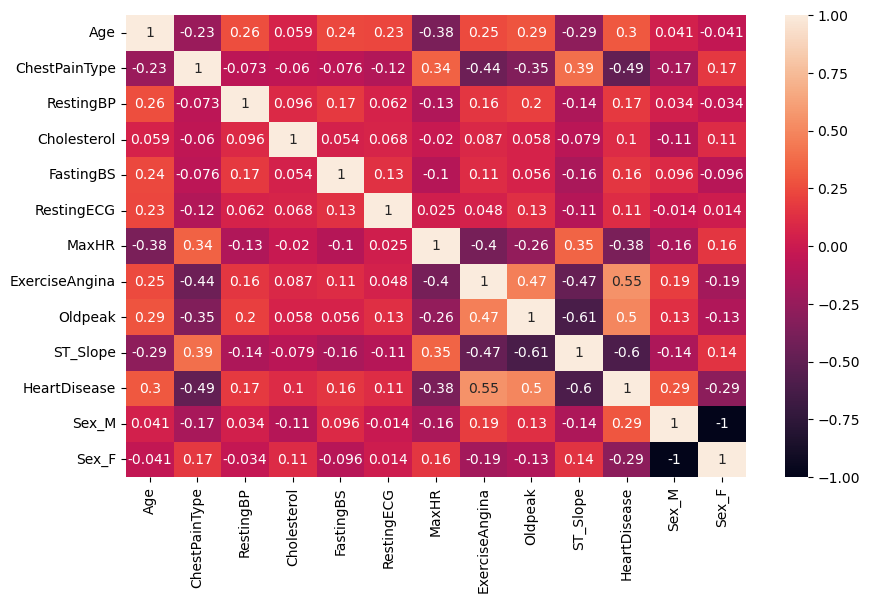

In [208]:
corr_mat_2 = df.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr_mat_2,
         annot=True)

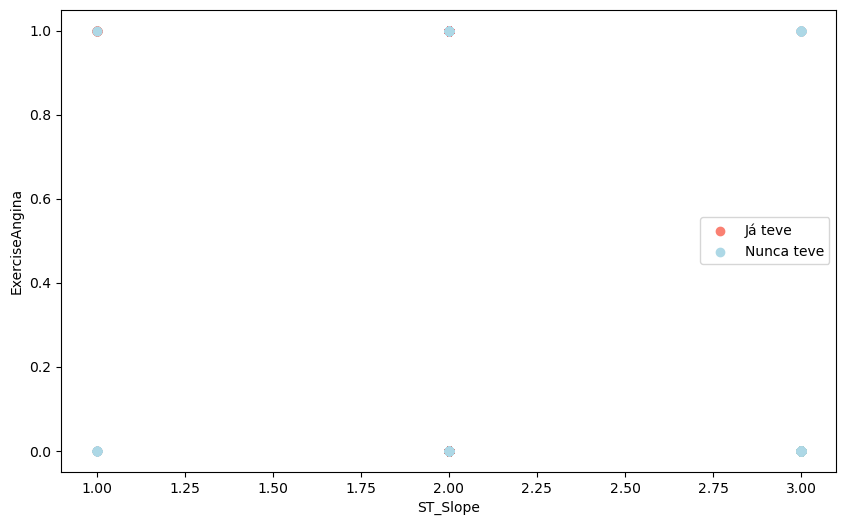

In [209]:
plt.figure(figsize=(10,6))
plt.scatter(df['ST_Slope'][df["HeartDisease"] == 1],
            df['ExerciseAngina'][df["HeartDisease"] == 1],
            c='salmon')
plt.scatter(df['ST_Slope'][df["HeartDisease"] == 0],
            df['ExerciseAngina'][df["HeartDisease"] == 0],
            c='lightblue')
plt.xlabel("ST_Slope")
plt.ylabel("ExerciseAngina")
plt.legend(["Já teve","Nunca teve"])

# Aplicando o Modelo

In [210]:
X = df.drop(columns=['HeartDisease'])
y = df['HeartDisease']


In [211]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,stratify=y,random_state=42)

In [212]:
#Treinando a minha Àrvore
from sklearn import tree
clf = tree.DecisionTreeClassifier()
clf.fit(X_train,y_train)

DecisionTreeClassifier()

In [213]:
clf.get_params()

{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': None,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': None,
 'splitter': 'best'}

In [214]:
#Testar a Minha Àrvore
clf.score(X_test,y_test)

0.8

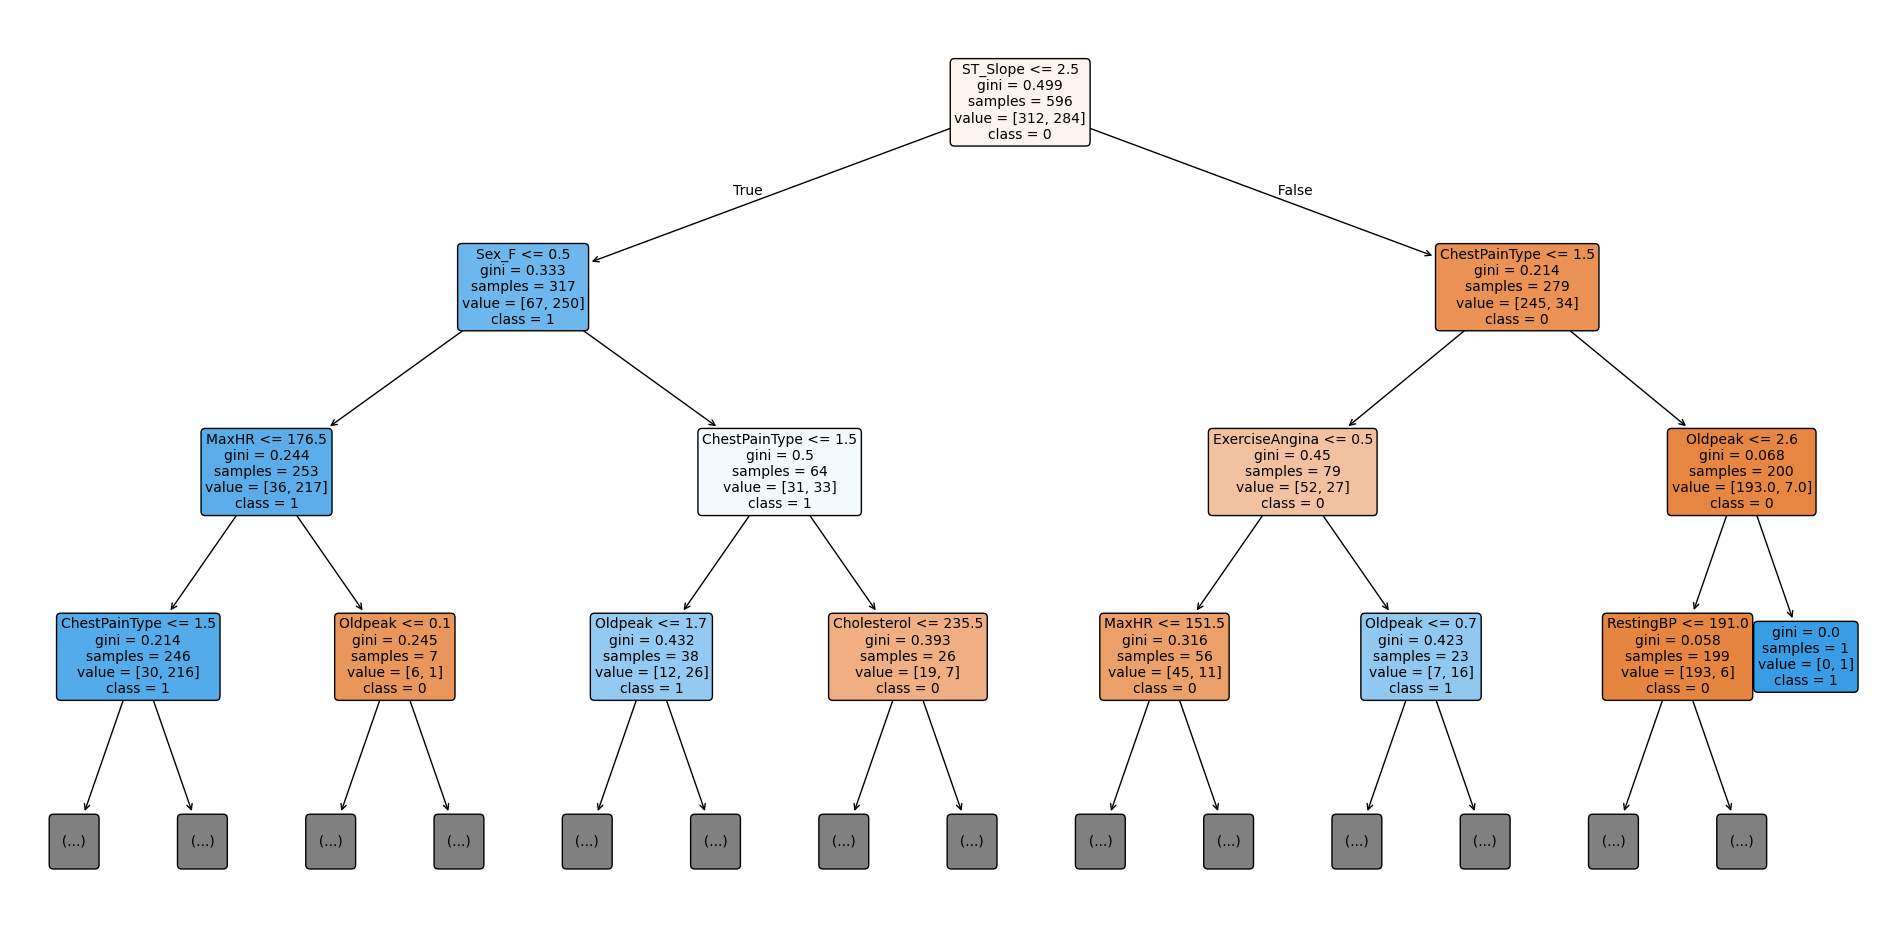

In [215]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(24, 12))
tree.plot_tree(
    clf,
    feature_names=X.columns,               
    class_names=[str(c) for c in clf.classes_],
    filled=True,
    rounded=True,
    max_depth=3,                           
    fontsize=10
)
plt.show()


In [216]:
y_pred = clf.predict(X_test)

Text(8.222222222222223, 0.5, 'Rótulos Previstos')

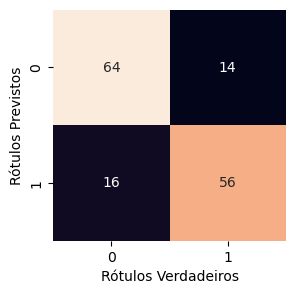

In [217]:
from sklearn.metrics import confusion_matrix

fig, ax = plt.subplots(figsize = (3,3))
ax = sns.heatmap(confusion_matrix(y_test,y_pred),
                 annot = True,
                 cbar = False)
plt.xlabel("Rótulos Verdadeiros")
plt.ylabel("Rótulos Previstos")

In [218]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81        78
           1       0.80      0.78      0.79        72

    accuracy                           0.80       150
   macro avg       0.80      0.80      0.80       150
weighted avg       0.80      0.80      0.80       150



# Ajustar os Hiperparâmtros

In [219]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint

param_dist = {
    "max_depth": [None] + list(range(2, 10)),
    "min_samples_split": randint(2, 101),
    "min_samples_leaf": randint(1, 51),
    "max_features": [None, "sqrt", "log2"],
    "criterion": ["gini", "entropy"],
    "class_weight": [None, "balanced"],
}

In [220]:
clf_random_search = RandomizedSearchCV(
    clf,
    param_distributions=param_dist,
    n_iter=80,
    scoring="precision",
    cv=10,
    random_state=42,
    n_jobs=-1
)

In [221]:
clf_random_search.fit(X_train,y_train)
clf_random_search.best_params_

{'class_weight': None,
 'criterion': 'entropy',
 'max_depth': 4,
 'max_features': 'log2',
 'min_samples_leaf': 7,
 'min_samples_split': 45}

In [222]:
clf_random_search.score(X_test,y_test)

0.8181818181818182

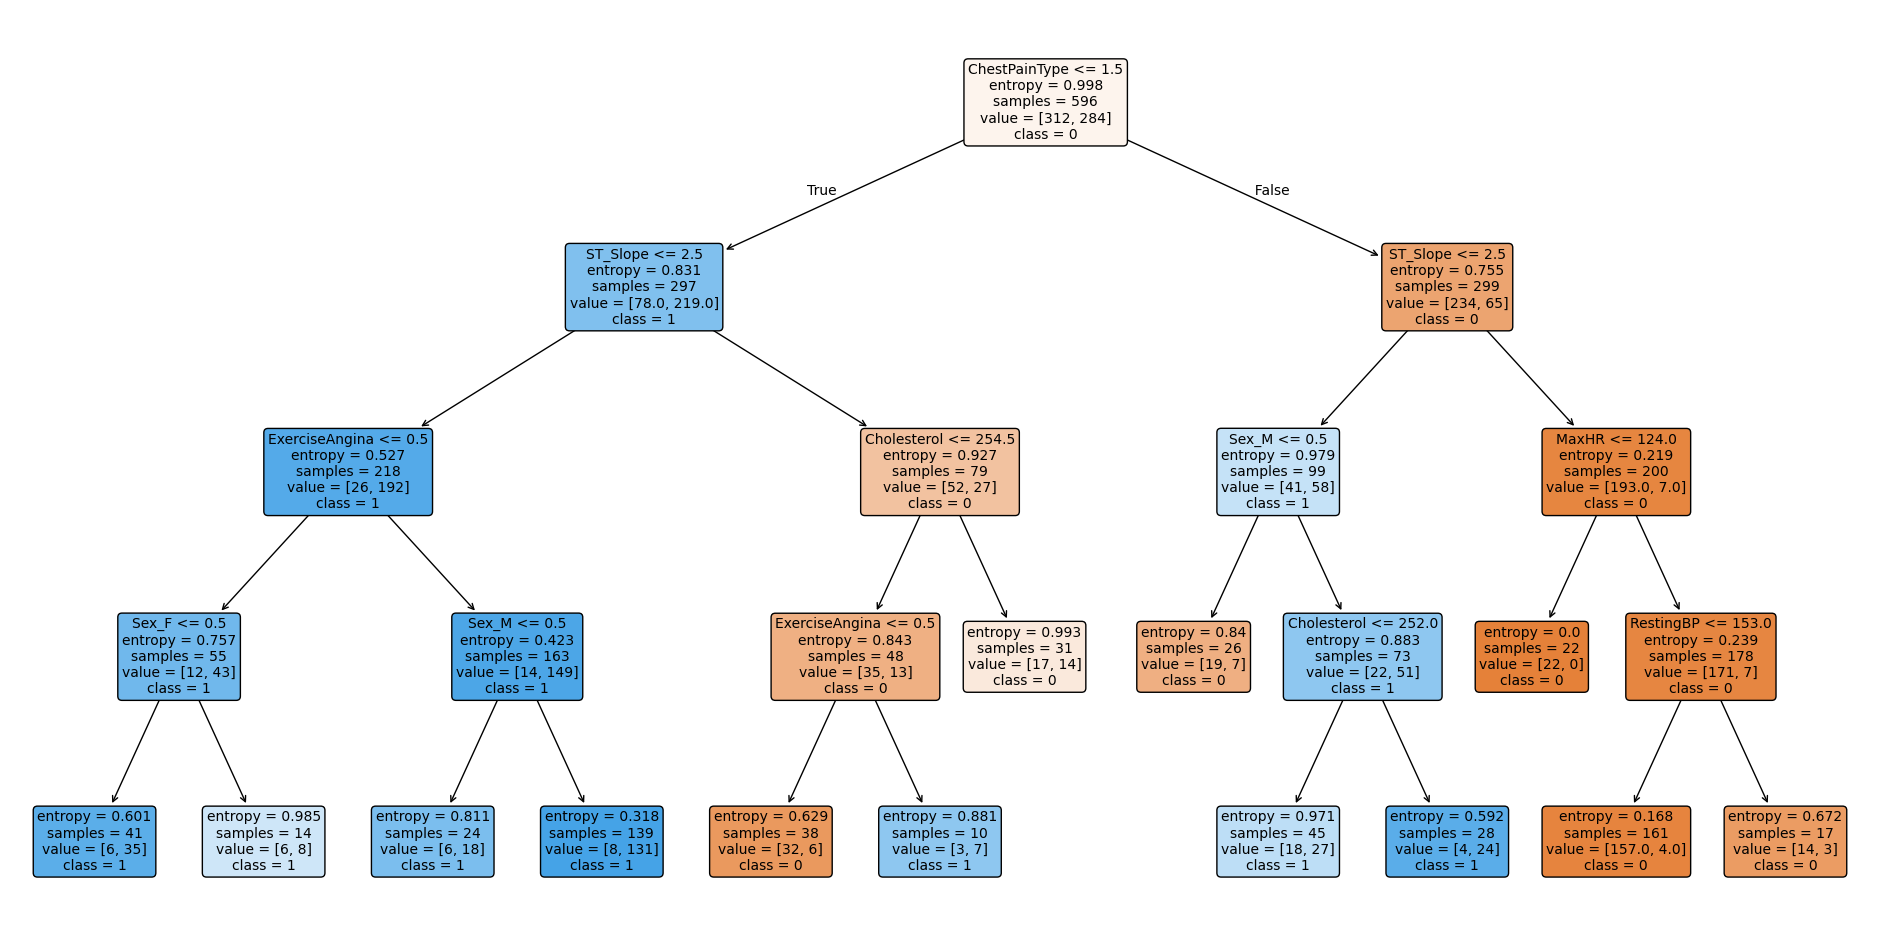

In [223]:
plt.figure(figsize=(24, 12))

melhor_arvore = clf_random_search.best_estimator_
tree.plot_tree(
    melhor_arvore,
    feature_names=X.columns,               
    class_names=[str(c) for c in clf_random_search.classes_],
    filled=True,
    rounded=True,
    max_depth=9,                           
    fontsize=10
)
plt.show()


In [224]:
#Comparando Treino e Teste :

from sklearn.metrics import precision_score

y_pred_train = melhor_arvore.predict(X_train)
y_pred_test = melhor_arvore.predict(X_test)

print(f"Precision Treino : {precision_score(y_train,y_pred_train)}")
print(f"Precision Teste : {precision_score(y_test,y_pred_test)}")

Precision Treino : 0.8305647840531561
Precision Teste : 0.8181818181818182


In [225]:
from sklearn.metrics import classification_report
print(classification_report(y_test, melhor_arvore.predict(X_test)))


              precision    recall  f1-score   support

           0       0.88      0.82      0.85        78
           1       0.82      0.88      0.85        72

    accuracy                           0.85       150
   macro avg       0.85      0.85      0.85       150
weighted avg       0.85      0.85      0.85       150



In [226]:
from sklearn.metrics import classification_report
print(classification_report(y_train, melhor_arvore.predict(X_train)))

              precision    recall  f1-score   support

           0       0.88      0.84      0.86       312
           1       0.83      0.88      0.85       284

    accuracy                           0.86       596
   macro avg       0.86      0.86      0.86       596
weighted avg       0.86      0.86      0.86       596

